# Lab 9


# Part A: Support Vector Machine (SVM)

## Task 1: Dataset Loading and Preprocessing

The Breast Cancer Wisconsin (Diagnostic) dataset was loaded using Scikit-learn. The dataset contains 569 samples and 30 numerical features used for binary classification.

The dataset was checked for missing values, and no missing values were found. The target variable contains two classes representing malignant and benign cases.

The feature data was stored separately from the target variable for use in the SVM classification model.

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(
    cancer.target,
    name="Target"
)

print("Dataset Shape:", X.shape)

print("\nFeature Names:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(cancer.target_names)

print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nFirst 5 Records:")
print(X.head())

Dataset Shape: (569, 30)

Feature Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target Classes:
['malignant' 'benign']

Missing Values:
0

First 5 Records:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3 

In [2]:
print("\nClass Distribution:")
print(y.value_counts())


Class Distribution:
Target
1    357
0    212
Name: count, dtype: int64


# Task 2: Train-Test Split and Feature Scaling

The dataset was divided into training and testing sets using an 80:20 ratio with `random_state=42`. Stratification was used to maintain the class distribution in both subsets.

Since SVM is sensitive to the scale of input features, StandardScaler was applied to standardize the features. The scaler was fitted only on the training data and then used to transform both the training and testing data. This prevents data leakage from the testing set.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [5]:
scaler.fit_transform(X_train)

array([[-1.07200079, -0.6584246 , -1.0880801 , ..., -1.35052668,
        -0.35265805, -0.54138003],
       [ 1.74874285,  0.06650173,  1.75115682, ...,  1.54991557,
         0.19107787, -0.1737386 ],
       [-0.97473376, -0.93112416, -0.99770871, ..., -1.70744192,
        -0.307734  , -1.21303263],
       ...,
       [ 0.39844772,  1.06867262,  0.50751384, ...,  1.53492543,
         0.16164487,  1.23754763],
       [ 0.85331409, -0.0380331 ,  0.9054796 , ...,  2.10455077,
         0.31035897,  0.36249578],
       [-0.91179628, -0.82431683, -0.87666079, ..., -0.51332734,
        -0.50756857,  1.30824791]], shape=(455, 30))

In [6]:
scaler.transform(X_test)

array([[ 1.56851278,  2.16401585,  1.74286587, ...,  1.20214432,
        -0.14043064,  0.90036171],
       [-0.84027641, -0.5970672 , -0.8741735 , ..., -1.10124064,
        -0.81429139, -0.71323608],
       [-0.07072262,  1.19138742,  0.03202768, ...,  0.57255843,
         1.14997397,  1.86841162],
       ...,
       [ 0.3583966 , -0.44935493,  0.48264098, ...,  1.63386036,
         0.54117564,  1.91191948],
       [-0.41401799,  1.07321761, -0.42314565, ...,  0.06139464,
        -0.1280378 ,  0.64747227],
       [-0.6829327 , -0.69932953, -0.66607058, ..., -0.23615965,
        -0.16211811, -0.20147486]], shape=(114, 30))

# Task 3: Linear Kernel SVM and Hyperparameter Tuning

A Support Vector Machine classifier with a linear kernel was trained using the standardized training data.

Hyperparameter tuning was performed using GridSearchCV by testing different values of the `C` parameter. Five-fold cross-validation was used to identify the value of `C` that produced the best validation performance.

The best hyperparameter combination was then used to create the optimized Linear SVM model, which was evaluated on the test dataset.

In [7]:
from sklearn.svm import SVC

svm_linear = SVC(
    kernel="linear",
    random_state=42
)

svm_linear.fit(X_train_scaled, y_train)

y_pred_svm = svm_linear.predict(X_test_scaled)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


In [8]:
print("Predictions:")
print(y_pred_svm)

Predictions:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [10]:
from sklearn.model_selection import GridSearchCV
# hyperparameter tuning for SVM using GridSearchCV
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_svm = GridSearchCV(
    SVC(kernel="linear", random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest Cross Validation Score:")
print(grid_svm.best_score_)

Best Parameters:
{'C': 0.1}

Best Cross Validation Score:
0.9802197802197803


In [11]:
best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)

print("Optimized Linear SVM trained successfully.")

Optimized Linear SVM trained successfully.


# Task 4: SVM Model Evaluation

The optimized Linear SVM classifier was evaluated on the test dataset using accuracy, precision, recall, F1-score, and confusion matrix.

Accuracy measures the overall proportion of correctly classified samples, while precision, recall, and F1-score provide a more detailed evaluation of the classification performance.

The confusion matrix shows the number of correctly and incorrectly classified samples for each class.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

print("SVM Evaluation")
print("-----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

SVM Evaluation
-----------------------
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


In [13]:
cm = confusion_matrix(y_test, y_pred_svm)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[41  1]
 [ 1 71]]


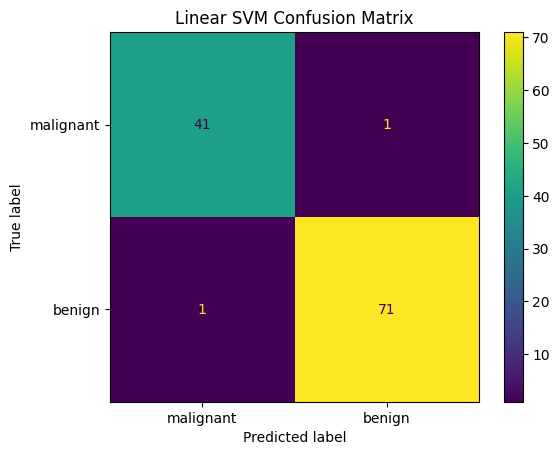

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
).plot()

plt.title("Linear SVM Confusion Matrix")
plt.show()

# Part B: Principal Component Analysis (PCA)

## Task 1: Dataset Loading and Feature Standardization

The Wine dataset was loaded using Scikit-learn. It contains 178 samples, 13 numerical features, and three target classes.

Before applying PCA, the features were standardized using StandardScaler. Standardization ensures that all features contribute on a comparable scale and prevents features with larger numerical ranges from dominating the principal component analysis.

In [15]:
import pandas as pd
from sklearn.datasets import load_wine

wine = load_wine()

X_wine = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

y_wine = pd.Series(
    wine.target,
    name="Target"
)

print("Dataset Shape:", X_wine.shape)

print("\nFeature Names:")
print(X_wine.columns.tolist())

print("\nFirst 5 Records:")
print(X_wine.head())

print("\nClass Distribution:")
print(y_wine.value_counts())

Dataset Shape: (178, 13)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

First 5 Records:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  

In [16]:
from sklearn.preprocessing import StandardScaler

scaler_wine = StandardScaler()

X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("Scaled Data Shape:", X_wine_scaled.shape)

Scaled Data Shape: (178, 13)


In [17]:
print("Mean of first feature:", X_wine_scaled[:, 0].mean())
print("Standard deviation of first feature:", X_wine_scaled[:, 0].std())

Mean of first feature: 7.94370811327303e-15
Standard deviation of first feature: 0.9999999999999997


# Task 2: PCA Dimensionality Reduction

PCA was applied to the standardized Wine dataset to reduce the original 13 features to 2 principal components. The transformed dataset therefore contains 178 samples and 2 principal components.


In [18]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2)

X_pca = pca_2.fit_transform(X_wine_scaled)

print("Original Shape:", X_wine_scaled.shape)
print("Transformed Shape:", X_pca.shape)

Original Shape: (178, 13)
Transformed Shape: (178, 2)


# Task 3: Explained Variance

The explained variance ratio was calculated to determine the amount of information captured by each principal component. The first principal component captures the largest proportion of the total variance, followed by the second principal component.


In [19]:
print("Explained Variance Ratio:")
print(pca_2.explained_variance_ratio_)

print("\nTotal Variance Retained by 2 Components:")
print(pca_2.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.36198848 0.1920749 ]

Total Variance Retained by 2 Components:
0.5540633835693529


# Task 4: Cumulative Explained Variance

Cumulative explained variance was calculated using all 13 principal components. The minimum number of components required to retain at least 95% of the total variance was identified from the cumulative variance values.

In [20]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_wine_scaled)

explained_variance = pca_full.explained_variance_ratio_

cumulative_variance = explained_variance.cumsum()

print("Explained Variance Ratio:")
print(explained_variance)

print("\nCumulative Explained Variance:")
print(cumulative_variance)

Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Cumulative Explained Variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


In [21]:
n_components_95 = (cumulative_variance >= 0.95).argmax() + 1

print("\nNumber of components required for 95% variance:",
      n_components_95)


Number of components required for 95% variance: 10


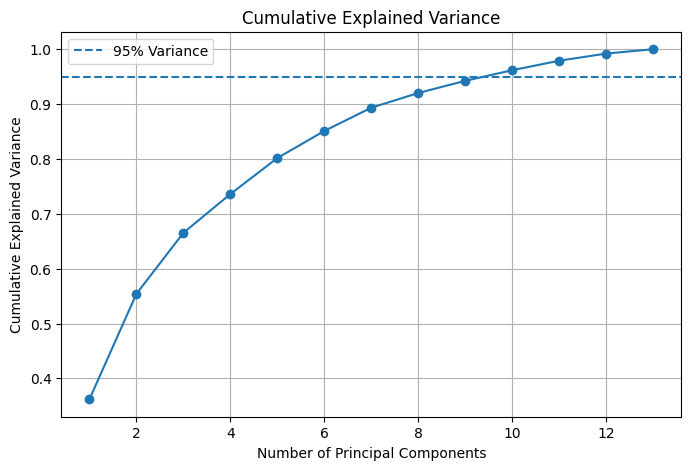

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Variance'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)

plt.show()

# Task 5: PCA Visualization

The Wine dataset was transformed from 13 original features into two principal components using PCA. A two-dimensional scatter plot was used to visualize the transformed data.

Each point represents a wine sample, and different classes are shown separately. The visualization helps identify whether the principal components preserve the separation between the different wine classes.

In [23]:
X_pca

array([[ 3.31675081,  1.44346263],
       [ 2.20946492, -0.33339289],
       [ 2.51674015,  1.0311513 ],
       [ 3.75706561,  2.75637191],
       [ 1.00890849,  0.86983082],
       [ 3.05025392,  2.12240111],
       [ 2.44908967,  1.17485013],
       [ 2.05943687,  1.60896307],
       [ 2.5108743 ,  0.91807096],
       [ 2.75362819,  0.78943767],
       [ 3.47973668,  1.30233324],
       [ 1.7547529 ,  0.61197723],
       [ 2.11346234,  0.67570634],
       [ 3.45815682,  1.13062988],
       [ 4.31278391,  2.09597558],
       [ 2.3051882 ,  1.66255173],
       [ 2.17195527,  2.32730534],
       [ 1.89897118,  1.63136888],
       [ 3.54198508,  2.51834367],
       [ 2.0845222 ,  1.06113799],
       [ 3.12440254,  0.78689711],
       [ 1.08657007,  0.24174355],
       [ 2.53522408, -0.09184062],
       [ 1.64498834, -0.51627893],
       [ 1.76157587, -0.31714893],
       [ 0.9900791 ,  0.94066734],
       [ 1.77527763,  0.68617513],
       [ 1.23542396, -0.08980704],
       [ 2.18840633,

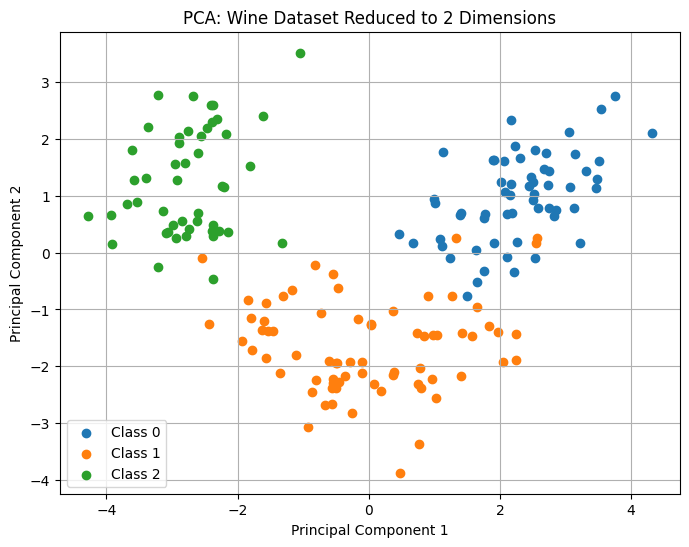

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for class_value in sorted(y_wine.unique()):
    plt.scatter(
        X_pca[y_wine == class_value, 0],
        X_pca[y_wine == class_value, 1],
        label=f"Class {class_value}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Wine Dataset Reduced to 2 Dimensions")
plt.legend()
plt.grid(True)

plt.show()

# Task 6: Original vs Transformed Dataset

The original Wine dataset contains 13 features, while the PCA-transformed dataset contains only 2 principal components.

PCA reduces the number of features significantly, which can improve computational efficiency and simplify visualization. However, reducing the dataset to two components results in some information loss, with the retained information corresponding to the combined explained variance of the first two principal components.

In [25]:
print("Original number of features:", X_wine.shape[1])
print("Transformed number of features:", X_pca.shape[1])

print(
    "Variance retained by 2 components:",
    pca_2.explained_variance_ratio_.sum()
)

Original number of features: 13
Transformed number of features: 2
Variance retained by 2 components: 0.5540633835693529


# Task 7: Interpretation of the First Two Principal Components

The contribution of each original feature to the first two principal components was analyzed using the PCA component loadings.

PC1 and PC2 are linear combinations of the original 13 features. Features with larger absolute loading values have a greater influence on the corresponding principal component.

The first principal component represents the direction of maximum variance in the dataset, while the second principal component represents the next highest direction of variance that is independent of the first component.

In [26]:
components = pd.DataFrame(
    pca_2.components_,
    columns=X_wine.columns,
    index=["PC1", "PC2"]
)

print(components)

      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
PC1  0.144329   -0.245188 -0.002051          -0.239320   0.141992   
PC2  0.483652    0.224931  0.316069          -0.010591   0.299634   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
PC1       0.394661    0.422934             -0.298533         0.313429   
PC2       0.065040   -0.003360              0.028779         0.039302   

     color_intensity       hue  od280/od315_of_diluted_wines   proline  
PC1        -0.088617  0.296715                      0.376167  0.286752  
PC2         0.529996 -0.279235                     -0.164496  0.364903  


In [27]:
print("\nTop contributors to PC1:")
print(
    components.loc["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head()
)

print("\nTop contributors to PC2:")
print(
    components.loc["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head()
)


Top contributors to PC1:
flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64

Top contributors to PC2:
color_intensity    0.529996
alcohol            0.483652
proline            0.364903
ash                0.316069
magnesium          0.299634
Name: PC2, dtype: float64


# Task 8: Advantages, Limitations, and Applications of PCA

## Advantages

- Reduces the number of features while retaining the maximum possible variance.
- Makes high-dimensional data easier to visualize.
- Reduces computational complexity and training time.
- Can help remove redundancy caused by correlated features.

## Limitations

- Some information is lost when the number of dimensions is reduced.
- Principal components are combinations of original features, so they can be difficult to interpret.
- PCA is sensitive to feature scaling, so standardization is generally required.
- PCA does not consider class labels because it is an unsupervised technique.

## Applications

PCA can be used for:

- Dimensionality reduction
- Data visualization
- Noise reduction
- Feature extraction
- Improving computational efficiency in machine learning

# Extra Credit: Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis was applied to the standardized Wine dataset to reduce the original 13 features to two linear discriminants.

Unlike PCA, which is an unsupervised dimensionality reduction technique that maximizes variance, LDA uses the class labels to maximize separation between different classes.

The transformed LDA data was visualized using a two-dimensional scatter plot and compared with the PCA visualization. LDA focuses on class separability, while PCA focuses on preserving overall variance in the dataset.

In [28]:
X_wine_scaled
y_wine

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: Target, Length: 178, dtype: int64

In [29]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X_wine_scaled, y_wine)

print("Original Shape:", X_wine_scaled.shape)
print("LDA Transformed Shape:", X_lda.shape)

Original Shape: (178, 13)
LDA Transformed Shape: (178, 2)


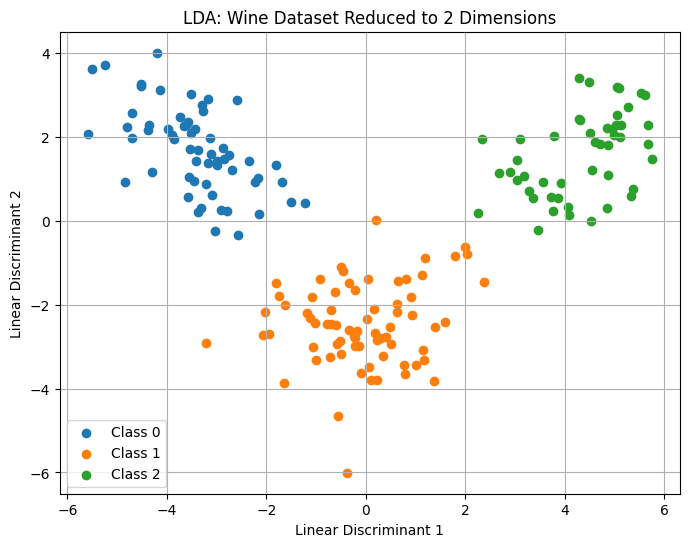

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for class_value in sorted(y_wine.unique()):
    plt.scatter(
        X_lda[y_wine == class_value, 0],
        X_lda[y_wine == class_value, 1],
        label=f"Class {class_value}"
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("LDA: Wine Dataset Reduced to 2 Dimensions")
plt.legend()
plt.grid(True)

plt.show()

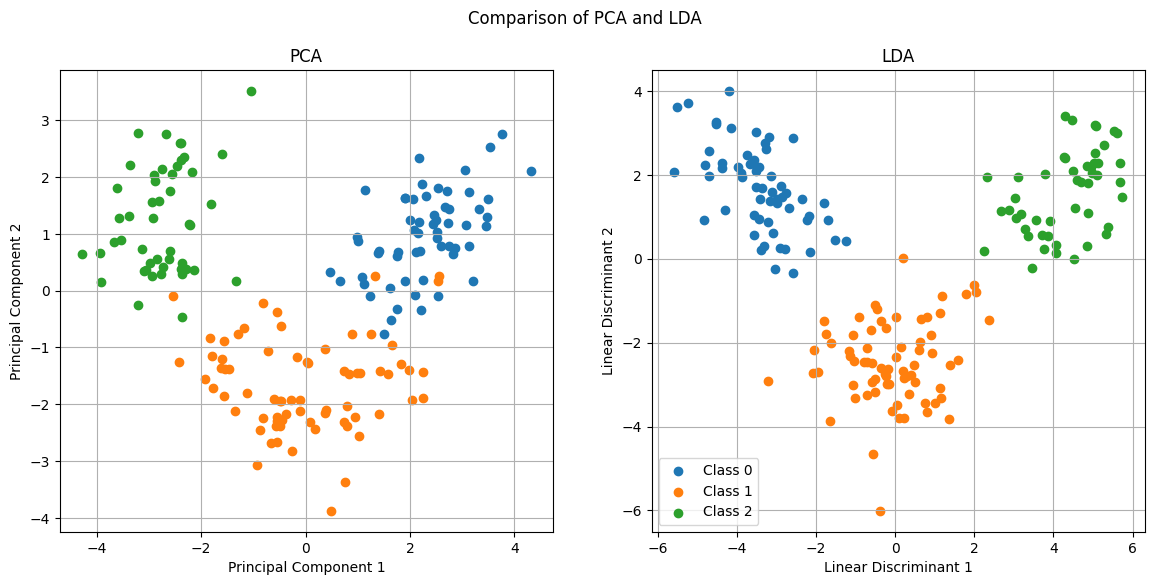

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
for class_value in sorted(y_wine.unique()):
    axes[0].scatter(
        X_pca[y_wine == class_value, 0],
        X_pca[y_wine == class_value, 1],
        label=f"Class {class_value}"
    )

axes[0].set_title("PCA")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].grid(True)

# LDA
for class_value in sorted(y_wine.unique()):
    axes[1].scatter(
        X_lda[y_wine == class_value, 0],
        X_lda[y_wine == class_value, 1],
        label=f"Class {class_value}"
    )

axes[1].set_title("LDA")
axes[1].set_xlabel("Linear Discriminant 1")
axes[1].set_ylabel("Linear Discriminant 2")
axes[1].grid(True)

axes[1].legend()

plt.suptitle("Comparison of PCA and LDA")
plt.show()